# **1. Environment installation**

This section installs the transformers model used for fine-tuning DNABERT-2.

In [5]:
!pip -q install -U "transformers==4.38.2" "peft==0.10.0" "accelerate==0.27.2" datasets scikit-learn
!pip -q uninstall -y triton

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.0/280.0 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 73.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.6.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.2 which is in

# **2. Import libraries**

The required Python libraries were imported.

In [1]:
import numpy as np # library used for arrays and mathematical operations
import pandas as pd # library for loading, manipulating, and analyzing tabular data
import torch # library for building and training deep learning models
import torch.nn as nn # PyTorch neural network module containing layers and loss functions
import time # used to measure the execution time of training and preprocessing steps
import os # library for file and directory management
import matplotlib.pyplot as plt # library for visualization plots

from datasets import (load_dataset, # downloads public datasets
                      Dataset, # converts pandas DataFrames into Hugging Face datasets
                      DatasetDict) # organizes datasets into train, validation, and test splits

from transformers import (AutoTokenizer, # tokenizes DNA sequences for DNABERT-2
                          AutoModel, # loads the pretrained DNABERT-2 model
                          Trainer, # simplifies model training and evaluation
                          TrainingArguments, # defines parameters
                          DataCollatorWithPadding) # dynamically pads sequences within each batch

# Loads the BERT configuration used by the DNABERT-2 backbone
from transformers.models.bert.configuration_bert import BertConfig

#  Stores the loss value and prediction logits returned during training and evaluation
from transformers.modeling_outputs import SequenceClassifierOutput

# Scikit-learn metrics used to evaluate the classification model
from sklearn.metrics import (accuracy_score,
                             precision_recall_fscore_support,
                             roc_auc_score,
                             ConfusionMatrixDisplay,
                             roc_curve,
                             auc)
# Computes class weights to compensate for class imbalance during training
from sklearn.utils.class_weight import compute_class_weight

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

# **3. Load the Pre-trained DNABERT-2 Model**

Loads the pretrained DNABERT-2 tokenizer and backbone model from Hugging Face.

In [2]:
# Name of the pretrained DNABERT-2 model hosted on Hugging Face:
model_name = "zhihan1996/DNABERT-2-117M"

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True) # trust_remote_code=True allows Hugging Face to use the custom tokenizer code

config = BertConfig.from_pretrained(model_name) # loads the model configuration

backbone = AutoModel.from_pretrained(model_name, config=config,trust_remote_code=True) # backbone generates contextual embeddings for DNA sequences but does
# not include a classification layer


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
A new version of the following files was downloaded from https://huggingface.co/zhihan1996/DNABERT-2-117M:
- bert_padding.py
- flash_attn_triton.py
. Make sure to double-check they do not contain any

# **4. Define the DNABERT-2 Classification Model**

First we compute a class weight to compensate for the imbalance between benign (0) and pathogenic (1) variants in the training dataset. Then we define a custom neural network by combining the pretrained DNABERT-2 backbone with a masked mean pooling layer, dropout regularization, and a linear classification layer.

In [17]:
class_weights = compute_class_weight(class_weight="balanced",
                                     classes=np.array([0, 1]), # the two class labels used for classification
                                     y=train_df["label"]) # training labels used to calculate class frequencies

class_weights = torch.tensor(class_weights, dtype=torch.float)

print(class_weights)

class DNABERT2Classifier(nn.Module):
    def __init__(self, backbone):
        super().__init__() # initialize the parent PyTorch module
        self.backbone = backbone # store the pretrained DNABERT-2 backbone model
        hidden_size = self.backbone.config.hidden_size # obtain the size of the hidden embeddings produced by DNABERT-2
        self.dropout = nn.Dropout(0.2) # randomly sets 20% of the features to zero
        self.classifier = nn.Linear(hidden_size, 2)

    def forward(self,
                input_ids=None,
                attention_mask=None,
                labels=None,):
        # Pass the tokenized DNA sequence through the pretrained DNABERT-2 model:
        outputs = self.backbone(input_ids=input_ids,
                                attention_mask=attention_mask,)
        if isinstance(outputs, tuple):
          hidden = outputs[0]
        else:
          hidden = outputs.last_hidden_state

        mask = attention_mask.unsqueeze(-1).float() # convert the attention mask to floating point and add one dimension
        pooled = (hidden * mask).sum(dim=1) # perform masked mean pooling
        pooled = pooled / mask.sum(dim=1).clamp(min=1e-9)
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled) # generate the raw prediction scores for the two classes
        loss = None

        loss = None

        if labels is not None:
          loss_fn = nn.CrossEntropyLoss(
            weight=class_weights.to(logits.device))
          loss = loss_fn(logits, labels.long())

        return SequenceClassifierOutput(loss=loss, logits=logits,)

model = DNABERT2Classifier(backbone)

print(type(model))

tensor([0.6355, 2.3445])


## **5. Load the data**

Load the training, validation, and test datasets generated during preprocessing, each CSV file contains the DNA sequence and its corresponding binary label.

In [19]:
train_df = pd.read_csv("train.csv")
valid_df = pd.read_csv("valid.csv")
test_df = pd.read_csv("test.csv")

# Convert the pandas DataFrames into Hugging Face Dataset objects
dataset = DatasetDict({"train": Dataset.from_pandas(train_df, preserve_index=False),
                       "validation": Dataset.from_pandas(valid_df, preserve_index=False),
                       "test": Dataset.from_pandas(test_df, preserve_index=False),
                       })

print(dataset)
print(dataset["train"].column_names)

print(train_df["label"].value_counts())
print(valid_df["label"].value_counts())
print(test_df["label"].value_counts())

DatasetDict({
    train: Dataset({
        features: ['sequence', 'label'],
        num_rows: 9800
    })
    validation: Dataset({
        features: ['sequence', 'label'],
        num_rows: 2100
    })
    test: Dataset({
        features: ['sequence', 'label'],
        num_rows: 2100
    })
})
['sequence', 'label']


# **6. Identify Sequence and Label Columns**

Automatically identifies the DNA sequence column and the corresponding label column, making the notebook adaptable to datasets with different column names.

In [21]:
columns = dataset["train"].column_names

seq_col = None
label_col = None

for col in columns:
    if col.lower() in ["sequence", "seq", "dna"]:
        seq_col = col
    if col.lower() in ["label", "labels"]:
        label_col = col

print(seq_col)
print(label_col)

sequence
label


# **7. Tokenization**

DNA sequences are tokenized using the DNABERT-2 tokenizer. The tokenized dataset is formatted for PyTorch, and dynamic padding is applied using a data collator to efficiently batch sequences of different lengths.

In [22]:
def tokenize_batch(batch): # the tokenizer converts each DNA sequence into numerical token IDs
    return tokenizer(batch[seq_col],
                     truncation=True,
                     max_length=512,)

tokenized_dataset = dataset.map(tokenize_batch, batched=True) # applies the tokenizer to the entire dataset
tokenized_dataset = tokenized_dataset.remove_columns([seq_col]) # removes the original DNA sequence column
tokenized_dataset.set_format(type="torch",
                             columns=["input_ids", "attention_mask","label"]) # converts the dataset into PyTorch tensors and specify

data_collator = DataCollatorWithPadding(tokenizer=tokenizer) # create a data collator that dynamically pads each batch

Map:   0%|          | 0/9800 [00:00<?, ? examples/s]

Map:   0%|          | 0/2100 [00:00<?, ? examples/s]

Map:   0%|          | 0/2100 [00:00<?, ? examples/s]

# **8. Evaluation Metrics**

Defines the evaluation metrics used to measure model performance, including Accuracy, Precision, Recall, F1-score, and ROC-AUC.

In [24]:
# Define a function to calculate the evaluation metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred # extract the model's raw prediction scores (logits)
    probs = torch.softmax(torch.tensor(logits),dim=1).numpy()
    preds = np.argmax(probs, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels,
                                                               preds,
                                                               average="binary")
    accuracy = accuracy_score(labels, preds)
    roc_auc = roc_auc_score(labels, probs[:,1])

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
    }

# **9. Define Training Parameters**

Training hyperparameters such as learning rate, batch size, number of epochs, weight decay, and checkpoint settings are defined using Hugging Face's TrainingArguments.

In [35]:
# Define the training configuration for fine-tuning the DNABERT-2 model
training_args = TrainingArguments(output_dir="./dnabert2_breast_cancer_model", # directory where the outputs will be saved
                                  evaluation_strategy="epoch", # evaluate the model after each training epoch
                                  save_strategy="epoch",
                                  learning_rate=2e-5, # learning rate used by the optimizer
                                  per_device_train_batch_size=4, # number of training samples processed
                                  per_device_eval_batch_size=8, # batch size
                                  num_train_epochs=5, # total number of times the model sees the entire training dataset
                                  weight_decay=0.01, # helps reduce overfitting
                                  logging_steps=50,
                                  load_best_model_at_end=True,
                                  metric_for_best_model="f1", # select the best model based on the validation F1-score
                                  greater_is_better=True,
                                  report_to="none",
                                  fp16=torch.cuda.is_available(),) # enables FP16 training when a compatible GPU is available

In [36]:
# Initializes the Hugging Face Trainer and fine-tunes the pretrained DNABERT-2
# model on the classification dataset:

trainer = Trainer(model=model,
                  args=training_args,
                  train_dataset=tokenized_dataset["train"],
                  eval_dataset=tokenized_dataset["test"],
                  tokenizer=tokenizer,
                  data_collator=data_collator,
                  compute_metrics=compute_metrics,)

start = time.time()

trainer.train()
test_results = trainer.evaluate(tokenized_dataset["validation"])

print(test_results)

test_results = trainer.evaluate(tokenized_dataset["test"])

end = time.time()

training_time = end - start

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")

trainer.save_model("./dnabert2_breast_cancer_model")
tokenizer.save_pretrained("./dnabert2_breast_cancer_model")

/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:450: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.693300,0.697932,0.212857,0.212857,1.000000,0.351001,0.522438
2,0.684300,0.688308,0.787143,0.000000,0.000000,0.000000,0.498495
3,0.694000,0.688308,0.787143,0.000000,0.000000,0.000000,0.523685
4,0.688500,0.688365,0.787143,0.000000,0.000000,0.000000,0.470152
5,0.681700,0.687842,0.787143,0.000000,0.000000,0.000000,0.506649


Checkpoint destination directory ./dnabert2_breast_cancer_model/checkpoint-2450 already exists and is non-empty. Saving will proceed but saved results may be invalid.
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
Checkpoint destination directory ./dnabert2_breast_cancer_model/checkpoint-4900 already exists and is non-empty. Saving will proceed but saved results may be invalid.
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
Checkpoint destination directory ./dnabe

{'eval_loss': 0.6972259879112244, 'eval_accuracy': 0.21333333333333335, 'eval_precision': 0.21333333333333335, 'eval_recall': 1.0, 'eval_f1': 0.3516483516483517, 'eval_roc_auc': 0.5198656660757524, 'eval_runtime': 5.9593, 'eval_samples_per_second': 352.392, 'eval_steps_per_second': 44.133, 'epoch': 5.0}
Training time: 1307.08 seconds
Training time: 21.78 minutes


('./dnabert2_breast_cancer_model/tokenizer_config.json',
 './dnabert2_breast_cancer_model/special_tokens_map.json',
 './dnabert2_breast_cancer_model/tokenizer.json')

In [37]:
# Evaluate the model performance

results = trainer.evaluate()
print(results)

{'eval_loss': 0.6979320049285889, 'eval_accuracy': 0.21285714285714286, 'eval_precision': 0.21285714285714286, 'eval_recall': 1.0, 'eval_f1': 0.3510011778563015, 'eval_roc_auc': 0.5224376802532443, 'eval_runtime': 6.8712, 'eval_samples_per_second': 305.624, 'eval_steps_per_second': 38.276, 'epoch': 5.0}


# **10. Generate Predictions**

This section generates predictions for the evaluation dataset and displays the true labels, predicted labels, and predicted probabilities for the first evaluation samples.

In [38]:
# Use the trained model to generate predictions on the test dataset
predictions = trainer.predict(tokenized_dataset["test"])

pred_labels = np.argmax(predictions.predictions, axis=1) # convert the raw prediction scores into predicted class labels

print(np.unique(pred_labels, return_counts=True))

probs = torch.softmax(torch.tensor(predictions.predictions),
                      dim=1).numpy() # convert the logits into probabilities

pred_labels = np.argmax(probs, axis=1)

true_labels = predictions.label_ids # retrieve the true labels from the test dataset

print("First 20 Evaluation Examples\n")

for i in range(20):
    print(f"Example {i+1}")
    print(f"True Label: {true_labels[i]}")
    print(f"Predicted Label: {pred_labels[i]}")
    print(f"Probability(label=1): {probs[i,1]:.4f}")
    print("-"*40)

(array([1]), array([2100]))
First 20 Evaluation Examples

Example 1
True Label: 0
Predicted Label: 1
Probability(label=1): 0.5176
----------------------------------------
Example 2
True Label: 0
Predicted Label: 1
Probability(label=1): 0.5175
----------------------------------------
Example 3
True Label: 1
Predicted Label: 1
Probability(label=1): 0.5176
----------------------------------------
Example 4
True Label: 0
Predicted Label: 1
Probability(label=1): 0.5176
----------------------------------------
Example 5
True Label: 1
Predicted Label: 1
Probability(label=1): 0.5176
----------------------------------------
Example 6
True Label: 0
Predicted Label: 1
Probability(label=1): 0.5176
----------------------------------------
Example 7
True Label: 0
Predicted Label: 1
Probability(label=1): 0.5176
----------------------------------------
Example 8
True Label: 0
Predicted Label: 1
Probability(label=1): 0.5176
----------------------------------------
Example 9
True Label: 1
Predicted Labe

# **11. Perform Inference on a new DNA Sequence**

This following function is designed to use the trained DNABERT-2 model to classify a single DNA sequence. Instead of evaluating an entire dataset, it takes one sequence as input and returns the predicted class along with the probability of each class.

In [39]:
# Defines a function that predicts whether a single DNA sequence belongs to class 0 or 1 using the trained DNABERT-2 model
def predict_promoter(sequence):
    model.eval()
    inputs = tokenizer(sequence,
                       return_tensors="pt",
                       truncation=True,
                       max_length=512,)

    # Move tensors to the same device as the model
    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(input_ids=inputs["input_ids"],
                        attention_mask=inputs["attention_mask"],)

    logits = outputs.logits
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    prediction = int(torch.argmax(logits, dim=1).item())

    return {
        "predicted_label": prediction,
        "prob_label_0": float(probs[0]),
        "prob_label_1": float(probs[1]),
    }

sequence = dataset["test"][0][seq_col]

print("Sequence:")
print(sequence)

prediction = predict_promoter(sequence)

print("\nPrediction:")
print(prediction)

Sequence:
TTAAAAAATAAAGCAAAATGTTATCAATGGATTAAACTATGAGACCATTTATTTCTTCCCTGCCCTGCAGCGTTCAGTGGGCTTACGCACCTCCGGCTGCCACCATGGGCTGCCCTGCAGGGAAGGCCTGTGTGAGGCAGACCTTTCAGGCCAGAGGAGGCTACACCACGGGCTCCCGCAGATTCTAGCAGGTGGGGGCATGAGACTTCAGGTCATAGGAGCAGACATCGCAGCCGTCCAGCAGGTCTGCCTGAGAGACGCCATTGAGGCTGGGGGCAACCAGAGCTCTGGGGTTGTCCTGCACGCCTGTCCTCGTGAGTGTGTCCTGGAGAAGTTCTCGGATTCTTCGGTTTTCCCTGAAGGTAGATTCCCAAATAACTTCAAGTTCACCTTCCATTTCT

Prediction:
{'predicted_label': 1, 'prob_label_0': 0.4824138581752777, 'prob_label_1': 0.5175861120223999}


# **12. Results**

Creates the figures to visualize the dataset and evaluate the model's performance.

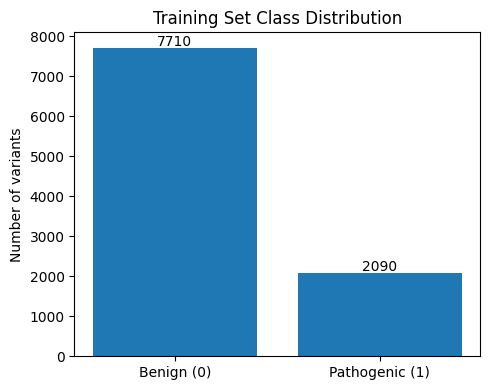

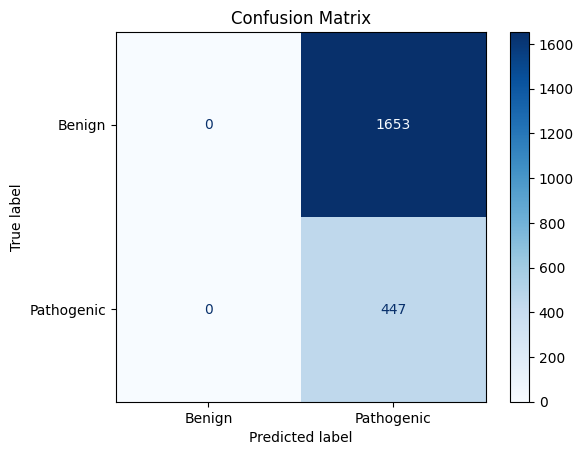

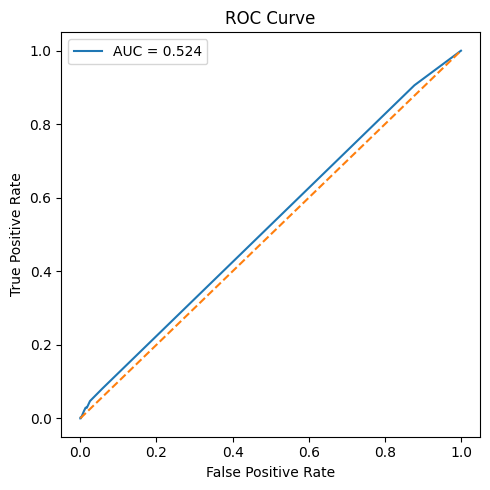

In [40]:
# Plot the class distribution
counts = train_df["label"].value_counts().sort_index() # count the number of samples belonging to each class in the training dataset
labels = ["Benign (0)", "Pathogenic (1)"]

plt.figure(figsize=(5,4))
plt.bar(labels, counts.values)
plt.ylabel("Number of variants")
plt.title("Training Set Class Distribution")

for i, v in enumerate(counts.values):
    plt.text(i, v + 50, str(v), ha="center") # display the number of samples above each bar

plt.tight_layout()
plt.show()

# Plot the confusion matrix
ConfusionMatrixDisplay.from_predictions(predictions.label_ids,
                                        pred_labels,
                                        display_labels=["Benign","Pathogenic"],
                                        cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# Create the ROC curve
probs = predictions.predictions[:,1]

fpr, tpr, _ = roc_curve(predictions.label_ids, probs) # compute the False Positive Rate (FPR) and True Positive Rate (TPR)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()